In [1]:
from pathlib import Path

MODEL='Version1'

DATASET_PATH=Path('preprocessed_data')

DATASET_PATH.mkdir(parents=True, exist_ok=True)

EVALUATE = False

In [2]:
import json
def get_word_files(dataset_path, isTr=False):
    with open(str(dataset_path / 'labels.json'), 'r') as fp:
        data_dict = json.load(fp)

    if isTr:
        words_files = list(data_dict['labels'].items())
    else:
        words_files = list(data_dict.items())
    print(words_files[0])
    print(f"{len(words_files)} words")
    return(data_dict)

In [3]:
kmnist_dict = get_word_files(DATASET_PATH / 'kmnist')
k49_dict = get_word_files(DATASET_PATH / 'K49')
kanjivg_dict = get_word_files(DATASET_PATH / 'kanjivg')
kkanji2_dict = get_word_files(DATASET_PATH / 'kkanji2')
tr_dict = get_word_files(DATASET_PATH / 'text_renderer', isTr=True)

kmnist_words = list(kmnist_dict.items())
k49_words = list(k49_dict.items())
kanjivg_words = list(kanjivg_dict.items())
kkanji2_words = list(kkanji2_dict.items())
tr_words = list(tr_dict['labels'].items())

words_list = [(kmnist_words, 'kmnist'), (k49_words, 'k49'), (kanjivg_words, 'kanjivg'), (kkanji2_words, 'kkanji2'), (tr_words, 'tr'),]

('preprocessed_data/kmnist/0.png', 'す')
240000 words
('preprocessed_data/K49/0.png', 'と')
929460 words
('preprocessed_data/kanjivg/鯏.png', '鯏')
1346499 words
('preprocessed_data/kkanji2/689fa55040ec4f03.png.png', '𤇆')
908309 words
('000000000', 'し')
100000 words


In [4]:
from typing import Tuple
import tqdm
import torch
from dtrocr.config import DTrOCRConfig
from torch.utils.data import DataLoader
import torch
torch.set_float32_matmul_precision('high')
from dtrocr.model import DTrOCRLMHeadModel

def evaluate_model(model: torch.nn.Module, dataloader: DataLoader) -> Tuple[float, float]:
    # set model to evaluation mode
    model.eval()
    
    losses, accuracies = [], []
    with torch.no_grad():
        for inputs in tqdm.tqdm(dataloader, total=len(dataloader), desc=f'Evaluating test set'):
            inputs = send_inputs_to_device(inputs, device=0)
            outputs = model(**inputs)
            
            losses.append(outputs.loss.item())
            accuracies.append(outputs.accuracy.item())
    
    loss = sum(losses) / len(losses)
    accuracy = sum(accuracies) / len(accuracies)
    
    # set model back to training mode
    model.train()
    
    return loss, accuracy

def send_inputs_to_device(dictionary, device):
    return {key: value.to(device=device) if isinstance(value, torch.Tensor) else value for key, value in dictionary.items()}



model = DTrOCRLMHeadModel(DTrOCRConfig())
model = torch.compile(model)
model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))
model.to(device=0)



/tmp/ipykernel_4203/4187205906.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'../models/{MODEL}.pt'))


OptimizedModule(
  (_orig_mod): DTrOCRLMHeadModel(
    (transformer): DTrOCRModel(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(4, 8), stride=(4, 8))
      )
      (token_embedding): Embedding(32000, 768)
      (positional_embedding): Embedding(256, 768)
      (hidden_layers): ModuleList(
        (0-11): 12 x GPT2Block(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): GPT2SdpaAttention(
            (c_attn): Conv1D()
            (c_proj): Conv1D()
            (attn_dropout): Dropout(p=0.1, inplace=False)
            (resid_dropout): Dropout(p=0.1, inplace=False)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): GPT2MLP(
            (c_fc): Conv1D()
            (c_proj): Conv1D()
            (act): NewGELUActivation()
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
      )
      (dropout): Dropout(p=0.1, inplace=False)


In [5]:
from dtrocr.processor import DTrOCRProcessor
from dtrocr.config import DTrOCRConfig
from pathlib import Path
from dataclasses import dataclass
from PIL import Image
from torch.utils.data import Dataset
  
@dataclass
class Word:
    file_path: Path
    transcription: str
    

def get_word(word_file, isTr=False):
    words = []
    file_path = str(DATASET_PATH / 'text_renderer' / 'images' / (word_file[0] + '.jpg')) if isTr else word_file[0]
    words.append(
        Word(
            file_path=file_path,
            transcription=word_file[1]
        )
    )
    return words
    
class IAMDataset(Dataset):
    def __init__(self, words: list[Word], config: DTrOCRConfig):
        super(IAMDataset, self).__init__()
        self.words = words
        self.processor = DTrOCRProcessor(config, add_eos_token=True, add_bos_token=True)
        
    def __len__(self):
        return len(self.words)
    
    def __getitem__(self, item):
        inputs = self.processor(
            images=Image.open(self.words[item].file_path).convert('RGB'),
            texts='',
            padding='max_length',
            return_tensors="pt",
            return_labels=True,
        )
        return {
            'pixel_values': inputs.pixel_values[0],
            'input_ids': inputs.input_ids[0],
            'attention_mask': inputs.attention_mask[0],
            'labels': inputs.labels[0]
        }

config = DTrOCRConfig(
    # attn_implementation='flash_attention_2'
)




In [6]:
import tqdm
import multiprocessing as mp

train_word_records = {}
for pair in words_list:
    isTr = pair[1] == 'tr'
    args = zip(pair[0], [isTr]* len(pair[0]))
    with mp.Pool(processes=mp.cpu_count()) as pool:
        word_list = list(
            tqdm.tqdm(
                pool.imap(get_word, pair[0]), 
                total=len(pair[0]),
                desc='Building dataset'
            )
        )
    words = [word for words_array in word_list for word in words_array]
    train_word_records[pair[1]] = words
    print(words[0])
    if EVALUATE:
        data = IAMDataset(words=words, config=config)
        dataloader = DataLoader(data, batch_size=32, shuffle=True, num_workers=mp.cpu_count())
        loss, accuracy = evaluate_model(model, dataloader)
            
        print(f"{pair[1]} loss: {loss}, accuracy: {accuracy}")

Building dataset: 100%|██████████| 240000/240000 [00:49<00:00, 4836.80it/s]


Word(file_path='preprocessed_data/kmnist/0.png', transcription='す')


Building dataset: 100%|██████████| 929460/929460 [03:09<00:00, 4917.10it/s]


Word(file_path='preprocessed_data/K49/0.png', transcription='と')


Building dataset: 100%|██████████| 1346499/1346499 [04:32<00:00, 4936.05it/s]


Word(file_path='preprocessed_data/kanjivg/鯏.png', transcription='鯏')


Building dataset: 100%|██████████| 908309/908309 [02:56<00:00, 5143.19it/s]


Word(file_path='preprocessed_data/kkanji2/689fa55040ec4f03.png.png', transcription='𤇆')


Building dataset: 100%|██████████| 100000/100000 [00:23<00:00, 4220.84it/s]


Word(file_path='000000000', transcription='し')


In [9]:
from dtrocr.processor import DTrOCRProcessor
from dtrocr.config import DTrOCRConfig

model.eval()
model.to('cpu')
test_processor = DTrOCRProcessor(DTrOCRConfig())

Word(file_path='preprocessed_data/kanjivg/剣.png', transcription='剣')
剣   <s></s></s>   tensor([[1, 2]])


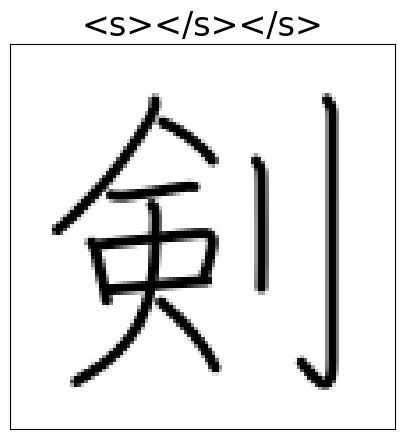

x   <s></s></s>   tensor([[1, 2]])


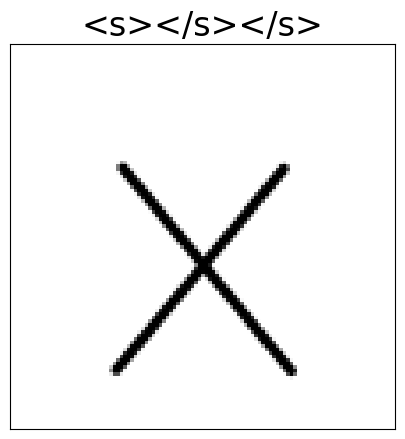

肄   <s></s></s>   tensor([[1, 2]])


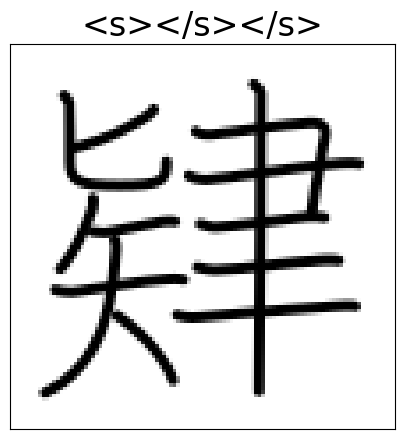

昿   <s></s></s>   tensor([[1, 2]])


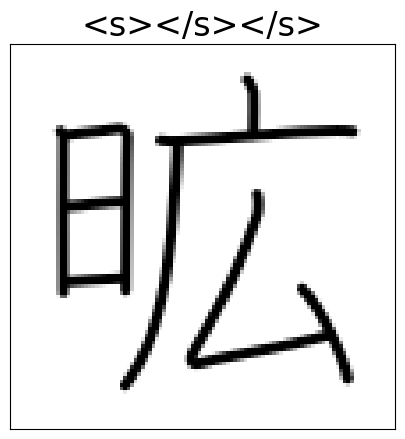

惷   <s></s></s>   tensor([[1, 2]])


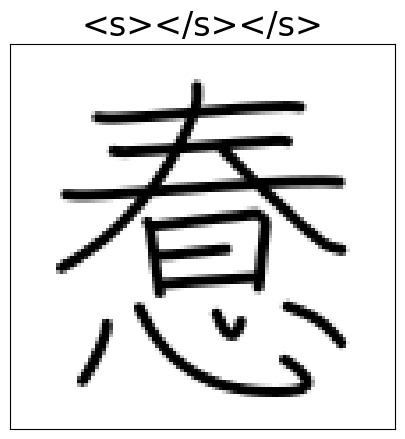

来   <s></s></s>   tensor([[1, 2]])


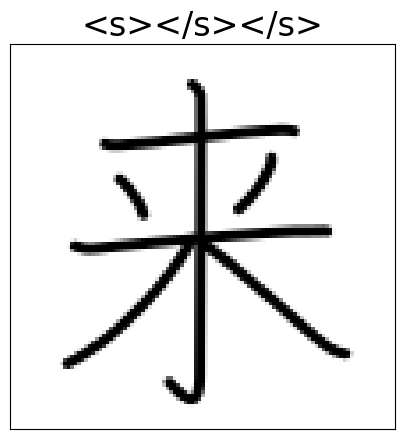

こ   <s></s></s>   tensor([[1, 2]])


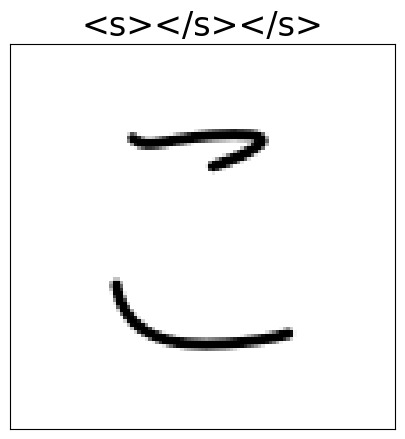

桟   <s></s></s>   tensor([[1, 2]])


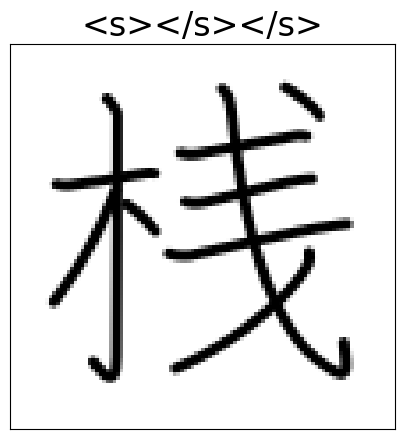

聹   <s></s></s>   tensor([[1, 2]])


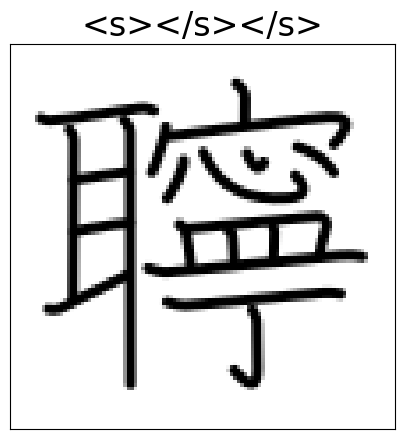

掠   <s></s></s>   tensor([[1, 2]])


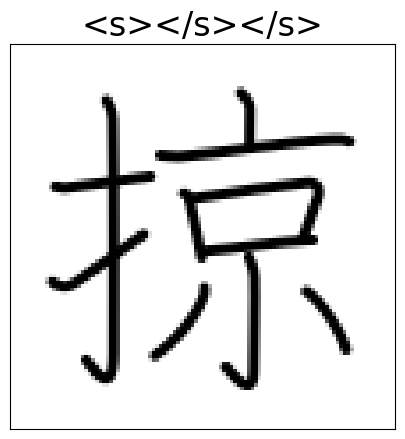

鯰   <s></s></s>   tensor([[1, 2]])


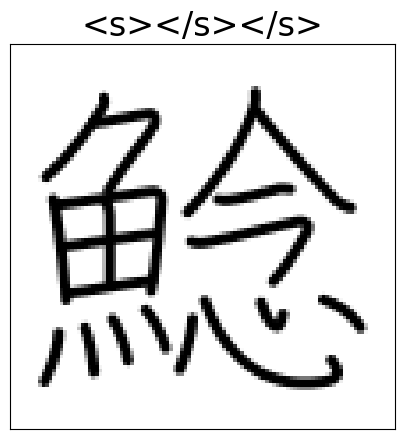

滷   <s></s></s>   tensor([[1, 2]])


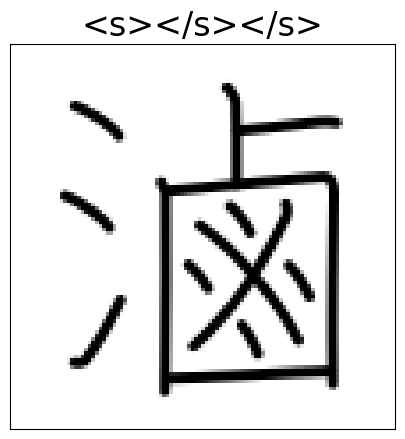

悠   <s></s></s>   tensor([[1, 2]])


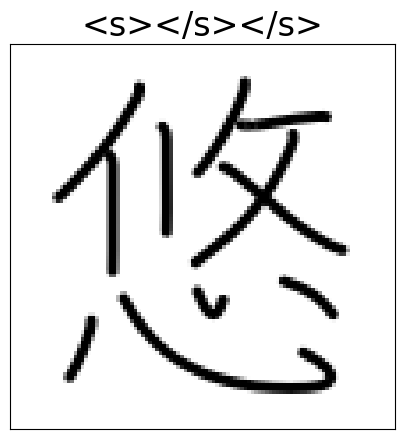

寶   <s></s></s>   tensor([[1, 2]])


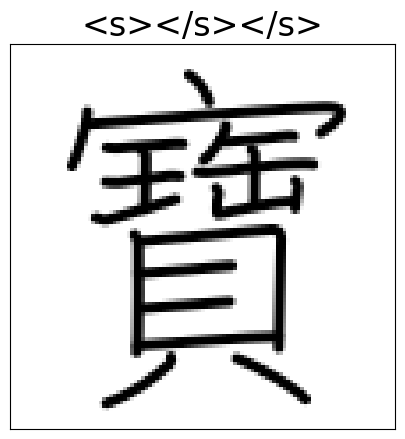

鎔   <s></s></s>   tensor([[1, 2]])


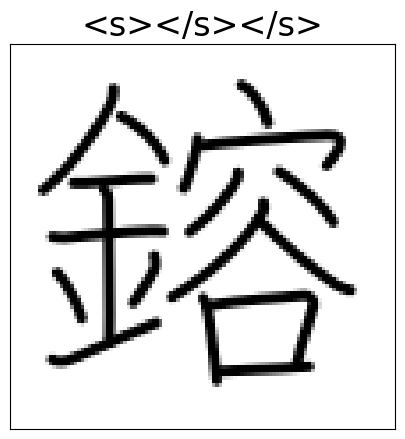

餔   <s></s></s>   tensor([[1, 2]])


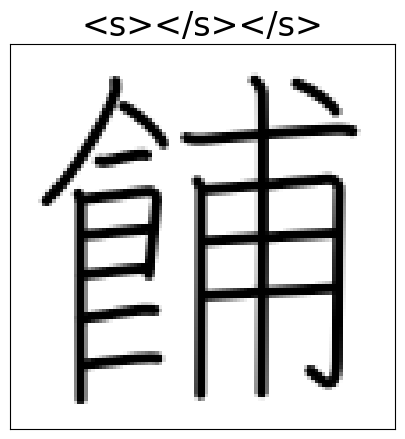

亦   <s></s></s>   tensor([[1, 2]])


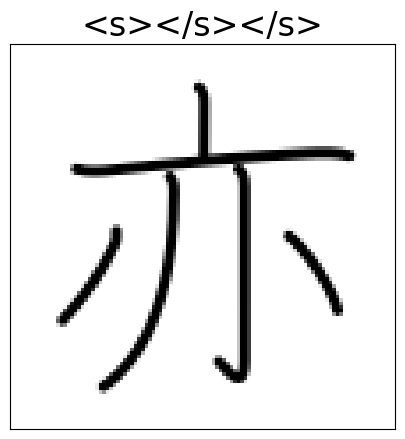

綴   <s></s></s>   tensor([[1, 2]])


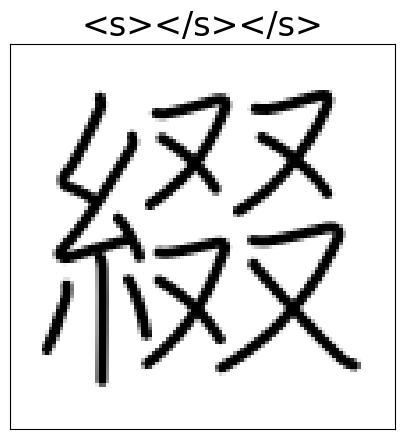

裨   <s></s></s>   tensor([[1, 2]])


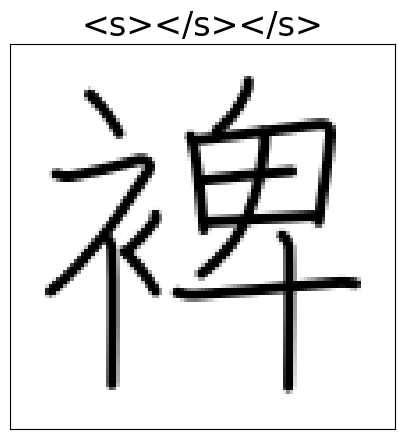

望   <s></s></s>   tensor([[1, 2]])


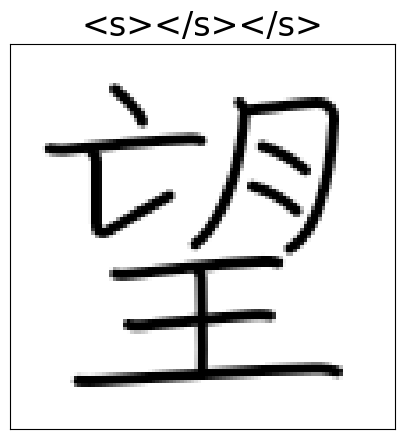

In [16]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

print(train_word_records['kanjivg'][10])

for test_word_record in train_word_records['kanjivg'][10:30]:
    image_file = test_word_record.file_path
    image = Image.open(image_file).convert('RGB')
    
    inputs = test_processor(
        images=image, 
        texts=test_processor.tokeniser.bos_token,
        return_tensors='pt'
    )
    
    model_output = model.generate(
        inputs, 
        test_processor,
        num_beams=1
    )
    
    predicted_text = test_processor.tokeniser.decode(model_output[0], skip_special_tokens=False)
    
    print(test_word_record.transcription, ' ', predicted_text, ' ', inputs.input_ids)
    plt.figure(figsize=(10, 5))
    plt.title(predicted_text, fontsize=24)
    plt.imshow(np.array(image, dtype=np.uint8))
    plt.xticks([]), plt.yticks([])
    plt.show()